C:\Users\User\AppData\Local\Temp\ipykernel_1948\198014454.py:5: DtypeWarning: Columns (0: medal) have mixed types. Specify dtype option on import or set low_memory=False.
  df_results = pd.read_csv('../../raw/world_olympedia_olympics_athlete_event_result.csv')


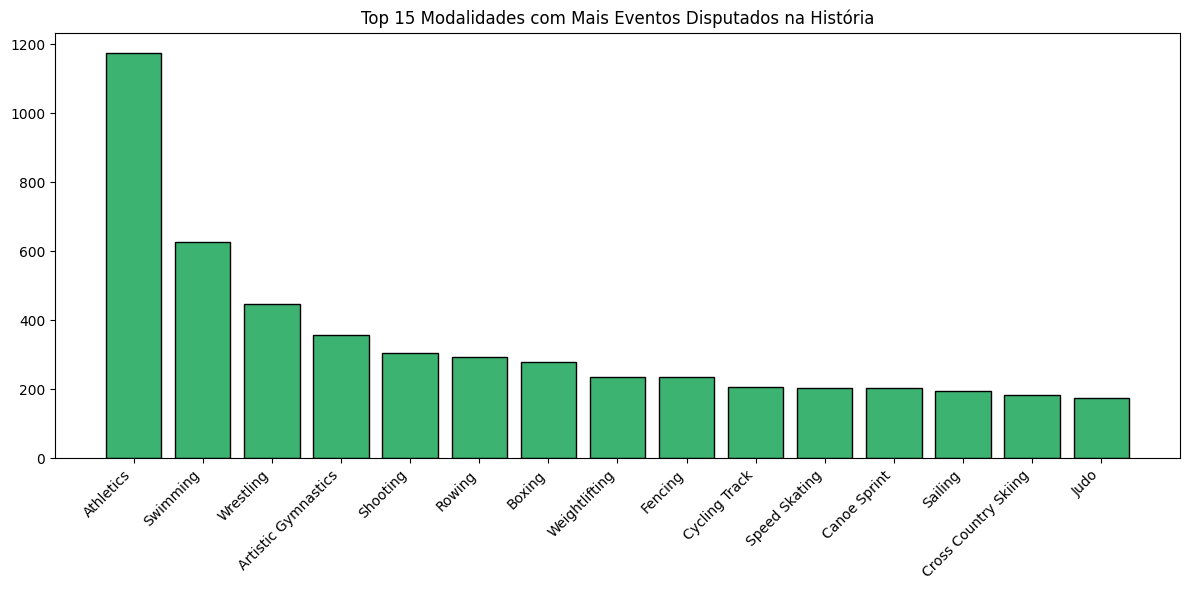

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Ler dados brutos
df_results = pd.read_csv('../../raw/world_olympedia_olympics_athlete_event_result.csv')
df_events_paris = pd.read_csv('../../raw/events.csv')

# 2. Padronizar e Consolidar (Edição, Esporte, Evento)
df_hist_mod = df_results[['edition', 'sport', 'event']].drop_duplicates()

df_paris_mod = df_events_paris[['sport', 'event']].drop_duplicates()
df_paris_mod['edition'] = '2024 Summer Olympics'

df_modalidades = pd.concat([df_hist_mod, df_paris_mod], ignore_index=True)

# 3. Salvar em Parquet (BRONZE)
df_modalidades.to_parquet('../../bronze/modalidades_1986_2024.parquet', index=False)

# 4. Gerar Sumário e Gráfico (GOLD) - Top 15 Esportes com mais eventos diferentes
df_gold_mod = df_modalidades['sport'].value_counts().reset_index().head(15)
df_gold_mod.columns = ['Modalidade', 'Total_Eventos_Disputados']
df_gold_mod.to_csv('modalidades_summary.csv', index=False)

plt.figure(figsize=(12, 6))
plt.bar(df_gold_mod['Modalidade'], df_gold_mod['Total_Eventos_Disputados'], color='mediumseagreen', edgecolor='black')
plt.title('Top 15 Modalidades com Mais Eventos Disputados na História')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('modalidades_plot.png')
plt.show()